# Node Classification with Graph Neural Networks

**Author:** [Khalid Salama](https://www.linkedin.com/in/khalid-salama-24403144/)<br>
**Date created:** 2021/05/30<br>
**Last modified:** 2021/05/30<br>
**Description:** Implementing a graph neural network model for predicting the topic of a paper given its citations.

## Introduction

Many datasets in various machine learning (ML) applications have structural relationships
between their entities, which can be represented as graphs. Such application includes
social and communication networks analysis, traffic prediction, and fraud detection.
[Graph representation Learning](https://www.cs.mcgill.ca/~wlh/grl_book/)
aims to build and train models for graph datasets to be used for a variety of ML tasks.

This example demonstrate a simple implementation of a [Graph Neural Network](https://arxiv.org/abs/1901.00596)
(GNN) model. The model is used for a node prediction task on the [Cora dataset](https://relational.fit.cvut.cz/dataset/CORA)
to predict the subject of a paper given its words and citations network.

Note that, **we implement a Graph Convolution Layer from scratch** to provide better
understanding of how they work. However, there is a number of specialized TensorFlow-based
libraries that provide rich GNN APIs, such as [Spectral](https://graphneural.network/),
[StellarGraph](https://stellargraph.readthedocs.io/en/stable/README.html), and
[GraphNets](https://github.com/deepmind/graph_nets).

## Setup

In [1]:
import os

# Choose backend: "jax", "torch", or "tensorflow"
os.environ["KERAS_BACKEND"] = "tensorflow"
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib

# matplotlib.use("Agg")  # Use non-interactive backend
import matplotlib.pyplot as plt
import keras
from keras import layers, ops

keras.utils.set_random_seed(42)
rng = np.random.default_rng(42)

## Prepare and Download the Dataset

The Cora dataset consists of 2,708 scientific papers classified into one of seven classes.
The citation network consists of 5,429 links. Each paper has a binary word vector of size
1,433, indicating the presence of a corresponding word.
The dataset has two tap-separated files: `cora.cites` and `cora.content`.

1. The `cora.cites` includes the citation records with two columns:
`cited_paper_id` (target) and `citing_paper_id` (source).
2. The `cora.content` includes the paper content records with 1,435 columns:
`paper_id`, `subject`, and 1,433 binary features.

In [2]:
zip_file = keras.utils.get_file(
    fname="cora.tgz",
    origin="https://linqs-data.soe.ucsc.edu/public/lbc/cora.tgz",
    extract=True,
)
data_dir = os.path.join(os.path.dirname(zip_file), "cora_extracted", "cora")

168052/168052 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


In [12]:
data_dir

'/root/.keras/datasets/cora_extracted/cora'

In [17]:
!ls /root/.keras/datasets/cora_extracted/cora/

cora.cites  cora.content  README


In [18]:
!head /root/.keras/datasets/cora_extracted/cora/cora.content

31336	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	1	0	0	0	0	0	0	1	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	1	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	1	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	1	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	1	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	0	

In [20]:
!cat /root/.keras/datasets/cora_extracted/cora/README

This directory contains the a selection of the Cora dataset (www.research.whizbang.com/data).

The Cora dataset consists of Machine Learning papers. These papers are classified into one of the following seven classes:
		Case_Based
		Genetic_Algorithms
		Neural_Networks
		Probabilistic_Methods
		Reinforcement_Learning
		Rule_Learning
		Theory

The papers were selected in a way such that in the final corpus every paper cites or is cited by atleast one other paper. There are 2708 papers in the whole corpus. 

After stemming and removing stopwords we were left with a vocabulary of size 1433 unique words. All words with document frequency less than 10 were removed.


THE DIRECTORY CONTAINS TWO FILES:

The .content file contains descriptions of the papers in the following format:

		<paper_id> <word_attributes>+ <class_label>

The first entry in each line contains the unique string ID of the paper followed by binary values indicating whether each word in the vocabulary is present (indicated 

### Process and visualize the dataset

In [32]:
citations = pd.read_csv(
    os.path.join(data_dir, "cora.cites"),
    sep="\t",
    header=None,
    names=["target", "source"],
)
print("Citations shape:", citations.shape)

citations.sample(frac=1).head()  # display a sample of the `citations` DataFrame

Citations shape: (5429, 2)


,target,source
2778,32688,1717
2106,16843,1152991
3674,77758,1131745
309,910,34355
2015,15429,10169


Now let's load the papers data into a Pandas DataFrame.

In [33]:
column_names = ["paper_id"] + [f"term_{idx}" for idx in range(1433)] + ["subject"]
papers = pd.read_csv(
    os.path.join(data_dir, "cora.content"),
    sep="\t",
    header=None,
    names=column_names,
)
print("Papers shape:", papers.shape)

Papers shape: (2708, 1435)


Now we display a sample of the `papers` DataFrame. The DataFrame includes the `paper_id`
and the `subject` columns, as well as 1,433 binary column representing whether a term exists
in the paper or not.

In [34]:
print(papers.sample(5).T)

                             657              1254             2119  \
paper_id                    18833           123556           529165   
term_0                          0                0                0   
term_1                          0                0                0   
term_2                          0                0                0   
term_3                          0                0                0   
...                           ...              ...              ...   
term_1429                       0                0                0   
term_1430                       0                0                0   
term_1431                       0                0                0   
term_1432                       0                0                0   
subject    Reinforcement_Learning  Neural_Networks  Neural_Networks   

                         129              2336  
paper_id                35061           948147  
term_0                      0                0  


Let's display the count of the papers in each subject.

In [35]:
print(papers.subject.value_counts())

subject
Neural_Networks           818
Probabilistic_Methods     426
Genetic_Algorithms        418
Theory                    351
Case_Based                298
Reinforcement_Learning    217
Rule_Learning             180
Name: count, dtype: int64


We convert the paper ids and the subjects into zero-based indices.

In [36]:
class_values = sorted(papers["subject"].unique())
class_idx = {name: id for id, name in enumerate(class_values)}
num_classes = len(class_values)
paper_idx = {name: idx for idx, name in enumerate(sorted(papers["paper_id"].unique()))}

In [37]:
class_values

['Case_Based',
 'Genetic_Algorithms',
 'Neural_Networks',
 'Probabilistic_Methods',
 'Reinforcement_Learning',
 'Rule_Learning',
 'Theory']

In [38]:
class_idx

{'Case_Based': 0,
 'Genetic_Algorithms': 1,
 'Neural_Networks': 2,
 'Probabilistic_Methods': 3,
 'Reinforcement_Learning': 4,
 'Rule_Learning': 5,
 'Theory': 6}

In [39]:
num_classes

7

In [40]:
paper_idx

{np.int64(35): 0,
 np.int64(40): 1,
 np.int64(114): 2,
 np.int64(117): 3,
 np.int64(128): 4,
 np.int64(130): 5,
 np.int64(164): 6,
 np.int64(288): 7,
 np.int64(424): 8,
 np.int64(434): 9,
 np.int64(463): 10,
 np.int64(504): 11,
 np.int64(506): 12,
 np.int64(887): 13,
 np.int64(906): 14,
 np.int64(910): 15,
 np.int64(936): 16,
 np.int64(940): 17,
 np.int64(941): 18,
 np.int64(943): 19,
 np.int64(1026): 20,
 np.int64(1033): 21,
 np.int64(1034): 22,
 np.int64(1035): 23,
 np.int64(1213): 24,
 np.int64(1237): 25,
 np.int64(1246): 26,
 np.int64(1272): 27,
 np.int64(1365): 28,
 np.int64(1385): 29,
 np.int64(1481): 30,
 np.int64(1688): 31,
 np.int64(1694): 32,
 np.int64(1717): 33,
 np.int64(1786): 34,
 np.int64(1817): 35,
 np.int64(1919): 36,
 np.int64(1949): 37,
 np.int64(1951): 38,
 np.int64(1952): 39,
 np.int64(1953): 40,
 np.int64(1955): 41,
 np.int64(1956): 42,
 np.int64(1959): 43,
 np.int64(1997): 44,
 np.int64(1999): 45,
 np.int64(2354): 46,
 np.int64(2440): 47,
 np.int64(2653): 48,
 np

In [41]:
papers["paper_id"] = papers["paper_id"].apply(lambda name: paper_idx[name])
citations["source"] = citations["source"].apply(lambda name: paper_idx[name])
citations["target"] = citations["target"].apply(lambda name: paper_idx[name])
papers["subject"] = papers["subject"].apply(lambda value: class_idx[value])

In [42]:
papers["subject"][:5]

,subject
0,2
1,5
2,4
3,4
4,3


Now let's visualize the citation graph. Each node in the graph represents a paper,
and the color of the node corresponds to its subject. Note that we only show a sample of
the papers in the dataset.

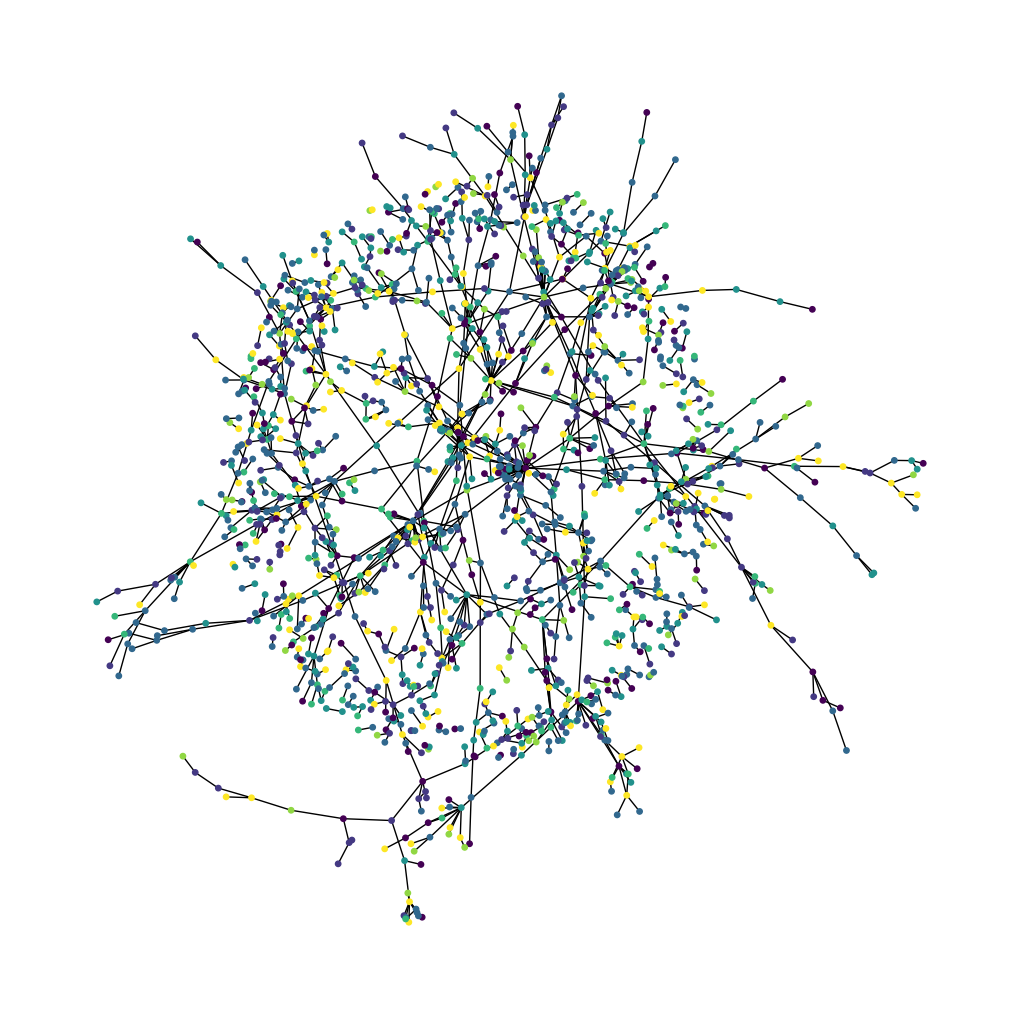

In [43]:
plt.figure(figsize=(10, 10))
colors = papers["subject"].tolist()
cora_graph = nx.from_pandas_edgelist(citations.sample(n=1500))
subjects = list(papers[papers["paper_id"].isin(list(cora_graph.nodes))]["subject"])
nx.draw_spring(cora_graph, node_size=15, node_color=subjects)
plt.show()

### Split the dataset into stratified train, validation, and test sets

In [44]:
train_ids, val_ids, test_ids = [], [], []
for cls, group in papers.groupby("subject"):
    ids = group["paper_id"].to_numpy().copy()
    rng.shuffle(ids)

    n = len(ids)
    n_train = int(0.50 * n)
    n_val = int(0.15 * n)

    train_ids.append(ids[:n_train])
    val_ids.append(ids[n_train : n_train + n_val])
    test_ids.append(ids[n_train + n_val :])

train_indices = np.concatenate(train_ids).astype("int32")
val_indices = np.concatenate(val_ids).astype("int32")
test_indices = np.concatenate(test_ids).astype("int32")

labels_by_id = papers.sort_values("paper_id")["subject"].to_numpy().astype("int32")
train_labels = labels_by_id[train_indices]
val_labels = labels_by_id[val_indices]
test_labels = labels_by_id[test_indices]

# Shuffle training nodes (good practice)
perm = rng.permutation(len(train_indices))
train_indices = train_indices[perm]
train_labels = train_labels[perm]

print("Train idx/labels:", train_indices.shape, train_labels.shape)
print("Val   idx/labels:", val_indices.shape, val_labels.shape)
print("Test  idx/labels:", test_indices.shape, test_labels.shape)

Train idx/labels: (1353,) (1353,)
Val   idx/labels: (402,) (402,)
Test  idx/labels: (953,) (953,)


## Implement Train and Evaluate Experiment

In [45]:
hidden_units = [32, 32]
dropout_rate = 0.5
learning_rate = 0.01
num_epochs = 300
batch_size = 256

This function compiles and trains an input model using the given training data.

In [47]:
def run_experiment(model, x_train, y_train, x_val, y_val):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), # task=classification -> Crossentropy, Multi Labels -> Categorical, No OneHot for Labels -> Sparse, No SoftMax for last Layer -> from_logits=True
        metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc")],
    )
    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=50,
        restore_best_weights=True,
    )
    history = model.fit(
        x=x_train,
        y=y_train,
        validation_data=(x_val, y_val),
        epochs=num_epochs,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=2,
    )
    return history


This function displays the loss and accuracy curves of the model during training.

In [48]:
def display_learning_curves(history, title=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    if title:
        fig.suptitle(title)

    ax1.plot(history.history["loss"])
    ax1.plot(history.history["val_loss"])
    ax1.legend(["train", "val"], loc="upper right")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")

    ax2.plot(history.history["acc"])
    ax2.plot(history.history["val_acc"])
    ax2.legend(["train", "val"], loc="upper right")
    ax2.set_xlabel("Epochs")
    ax2.set_ylabel("Accuracy")
    plt.show()


## Implement Feedforward Network (FFN) Module

We will use this module in the baseline and the GNN models.

In [49]:
def create_ffn(hidden_units, dropout_rate, name=None):
    ffn_layers = []
    for units in hidden_units:
        ffn_layers.append(layers.BatchNormalization())
        ffn_layers.append(layers.Dropout(dropout_rate))
        ffn_layers.append(layers.Dense(units, activation="gelu"))
    return keras.Sequential(ffn_layers, name=name)


## Build a Baseline Neural Network Model

### Prepare the data for the baseline model

In [50]:
papers.columns

Index(['paper_id', 'term_0', 'term_1', 'term_2', 'term_3', 'term_4', 'term_5',
       'term_6', 'term_7', 'term_8',
       ...
       'term_1424', 'term_1425', 'term_1426', 'term_1427', 'term_1428',
       'term_1429', 'term_1430', 'term_1431', 'term_1432', 'subject'],
      dtype='object', length=1435)

In [52]:
len(set(papers.columns))

1435

In [53]:
feature_names = [c for c in papers.columns if c not in ("paper_id", "subject")]
node_features_np = (
    papers.sort_values("paper_id")[feature_names].to_numpy().astype("float32")
)
edges_np = citations[["source", "target"]].to_numpy().T.astype("int32")

graph_info = (node_features_np, edges_np, None)

# For the baseline, x is just the node feature row for each node index.
x_train_base = node_features_np[train_indices]
x_val_base = node_features_np[val_indices]
x_test_base = node_features_np[test_indices]
num_features = node_features_np.shape[1]

In [54]:
x_train_base.shape

(1353, 1433)

### Implement a baseline classifier

We add five FFN blocks with skip connections, so that we generate a baseline model with
roughly the same number of parameters as the GNN models to be built later.

In [55]:
def create_baseline_model(hidden_units, num_classes, dropout_rate=0.2):
    inputs = layers.Input(shape=(num_features,), name="input_features")
    x = create_ffn(hidden_units, dropout_rate, name="ffn_block1")(inputs)
    for block_idx in range(4):
        x1 = create_ffn(hidden_units, dropout_rate, name=f"ffn_block{block_idx + 2}")(x)
        x = layers.Add(name=f"skip_connection{block_idx + 2}")([x, x1])
    logits = layers.Dense(num_classes, name="logits")(x)
    return keras.Model(inputs=inputs, outputs=logits, name="baseline")


baseline_model = create_baseline_model(hidden_units, num_classes, dropout_rate=0.2)
baseline_model.summary()

Model: "baseline"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_features      │ (None, 1433)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn_block1          │ (None, 32)        │     52,804 │ input_features[0… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn_block2          │ (None, 32)        │      2,368 │ ffn_block1[0][0]  │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_connection2    │ (None, 32)        │          0 │ ffn_block1[0][0], │
│ (Add)               │                   │            │ ffn_block2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn_block3          │ (None, 32)        │      2,368 │ skip_connection2… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_connection3    │ (None, 32)        │          0 │ skip_connection2… │
│ (Add)               │                   │            │ ffn_block3[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn_block4          │ (None, 32)        │      2,368 │ skip_connection3… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_connection4    │ (None, 32)        │          0 │ skip_connection3… │
│ (Add)               │                   │            │ ffn_block4[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn_block5          │ (None, 32)        │      2,368 │ skip_connection4… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_connection5    │ (None, 32)        │          0 │ skip_connection4… │
│ (Add)               │                   │            │ ffn_block5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logits (Dense)      │ (None, 7)         │        231 │ skip_connection5… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 62,507 (244.17 KB)

 Trainable params: 59,065 (230.72 KB)

 Non-trainable params: 3,442 (13.45 KB)

### Train the baseline classifier

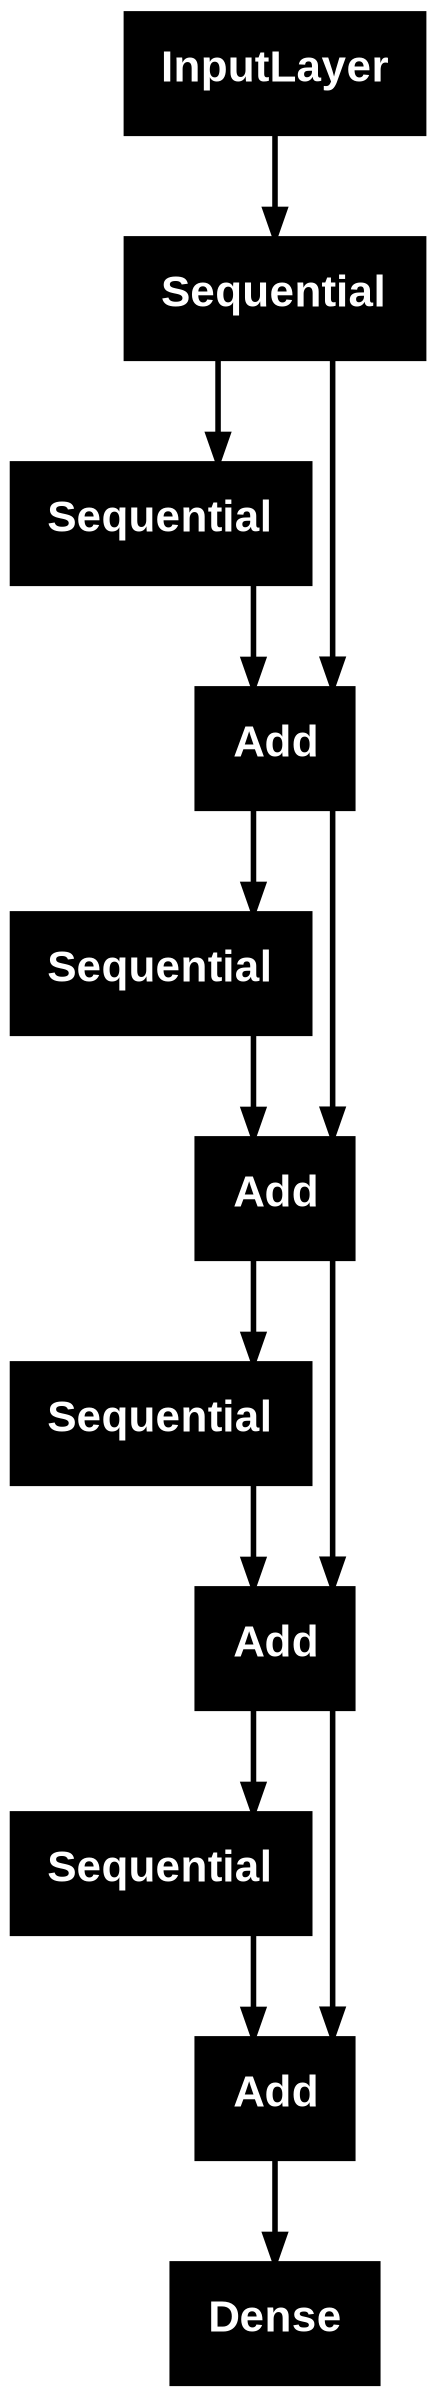

In [57]:
keras.utils.plot_model(baseline_model)

In [56]:
baseline_history = run_experiment(
    baseline_model,
    x_train_base,
    train_labels,
    x_val_base,
    val_labels,
)

Epoch 1/300
6/6 - 29s - 5s/step - acc: 0.2077 - loss: 2.8556 - val_acc: 0.1294 - val_loss: 1.9684
Epoch 2/300
6/6 - 18s - 3s/step - acc: 0.2772 - loss: 2.0090 - val_acc: 0.1294 - val_loss: 1.9281
Epoch 3/300
6/6 - 0s - 33ms/step - acc: 0.3799 - loss: 1.6398 - val_acc: 0.1667 - val_loss: 1.8902
Epoch 4/300
6/6 - 0s - 30ms/step - acc: 0.4745 - loss: 1.4199 - val_acc: 0.1816 - val_loss: 1.8179
Epoch 5/300
6/6 - 0s - 55ms/step - acc: 0.5831 - loss: 1.1778 - val_acc: 0.3259 - val_loss: 1.6308
Epoch 6/300
6/6 - 0s - 39ms/step - acc: 0.6578 - loss: 0.9966 - val_acc: 0.4677 - val_loss: 1.4649
Epoch 7/300
6/6 - 0s - 26ms/step - acc: 0.7347 - loss: 0.7573 - val_acc: 0.4478 - val_loss: 1.6395
Epoch 8/300
6/6 - 0s - 56ms/step - acc: 0.7953 - loss: 0.6203 - val_acc: 0.5522 - val_loss: 1.3809
Epoch 9/300
6/6 - 0s - 37ms/step - acc: 0.8285 - loss: 0.5189 - val_acc: 0.6095 - val_loss: 1.2787
Epoch 10/300
6/6 - 0s - 43ms/step - acc: 0.8677 - loss: 0.4124 - val_acc: 0.6418 - val_loss: 1.1543
Epoch 11/30

Let's plot the learning curves.

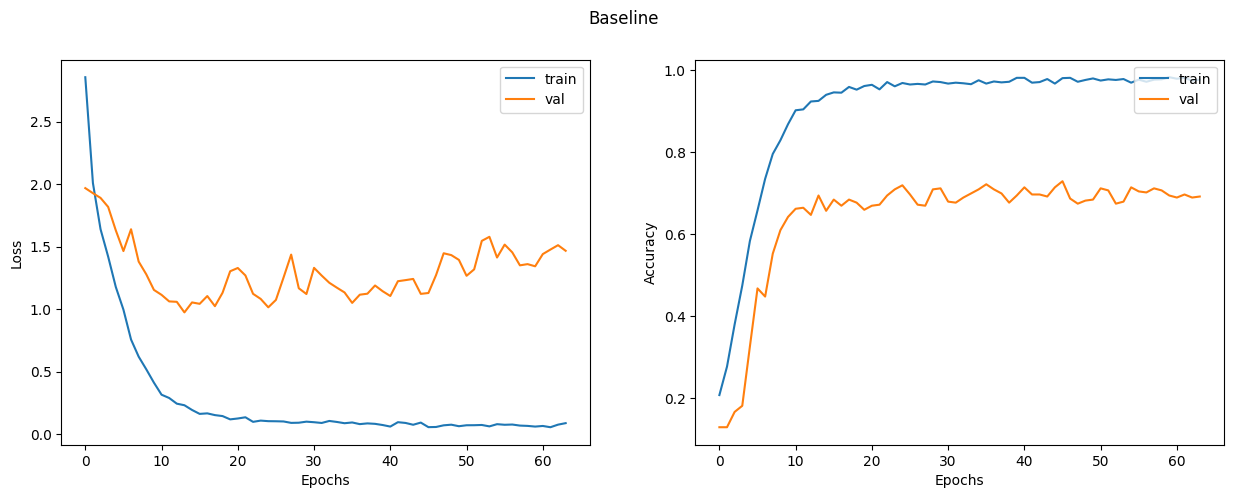

In [58]:
display_learning_curves(baseline_history, title="Baseline")

Now we evaluate the baseline model on the test data split.

In [59]:
_, test_accuracy = baseline_model.evaluate(x=x_test_base, y=test_labels, verbose=0)
print(f"Test accuracy: {round(test_accuracy * 100, 2)}%")


Test accuracy: 69.78%


### Examine the baseline model predictions

Let's create new data instances by randomly generating binary word vectors with respect to
the word presence probabilities.

In [60]:
def generate_random_instances(num_instances):
    token_probability = x_train_base.mean(axis=0)
    instances = []
    for _ in range(num_instances):
        probabilities = np.random.uniform(size=len(token_probability))
        instance = (probabilities <= token_probability).astype(int)
        instances.append(instance)

    return np.array(instances)


def display_class_probabilities(probabilities):
    for instance_idx, probs in enumerate(probabilities):
        print(f"Instance {instance_idx + 1}:")
        for class_idx, prob in enumerate(probs):
            print(f"- {class_values[class_idx]}: {round(prob * 100, 2)}%")


Now we show the baseline model predictions given these randomly generated instances.

In [61]:
new_instances = generate_random_instances(num_classes)
logits = baseline_model.predict(new_instances)
probabilities = ops.convert_to_numpy(
    keras.activations.softmax(ops.convert_to_tensor(logits))
)
display_class_probabilities(probabilities)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Instance 1:
- Case_Based: 2.7699999809265137%
- Genetic_Algorithms: 26.989999771118164%
- Neural_Networks: 53.66999816894531%
- Probabilistic_Methods: 10.630000114440918%
- Reinforcement_Learning: 2.880000114440918%
- Rule_Learning: 0.4099999964237213%
- Theory: 2.6600000858306885%
Instance 2:
- Case_Based: 0.6399999856948853%
- Genetic_Algorithms: 13.579999923706055%
- Neural_Networks: 13.170000076293945%
- Probabilistic_Methods: 66.48999786376953%
- Reinforcement_Learning: 0.46000000834465027%
- Rule_Learning: 4.5%
- Theory: 1.149999976158142%
Instance 3:
- Case_Based: 5.75%
- Genetic_Algorithms: 4.880000114440918%
- Neural_Networks: 13.600000381469727%
- Probabilistic_Methods: 53.970001220703125%
- Reinforcement_Learning: 4.46999979019165%
- Rule_Learning: 11.260000228881836%
- Theory: 6.079999923706055%
Instance 4:
- Case_Based: 0.5%
- Genetic_Algorithms: 25.809999465942383%
- Neural_Networks: 58.90999984741211%
- Probabilistic_Methods: 9.4399995

## Build a Graph Neural Network Model

### Prepare the data for the graph model

Preparing and loading the graphs data into the model for training is the most challenging
part in GNN models, which is addressed in different ways by the specialised libraries.
In this example, we show a simple approach for preparing and using graph data that is suitable
if your dataset consists of a single graph that fits entirely in memory.

The graph data is represented by the `graph_info` tuple, which consists of the following
three elements:

1. `node_features`: This is a `[num_nodes, num_features]` NumPy array that includes the
node features. In this dataset, the nodes are the papers, and the `node_features` are the
word-presence binary vectors of each paper.
2. `edges`:  This is `[num_edges, num_edges]` NumPy array representing a sparse
[adjacency matrix](https://en.wikipedia.org/wiki/Adjacency_matrix#:~:text=In%20graph%20theory%20and%20computer,with%20zeros%20on%20its%20diagonal.)
of the links between the nodes. In this example, the links are the citations between the papers.
3. `edge_weights` (optional): This is a `[num_edges]` NumPy array that includes the edge weights, which *quantify*
the relationships between nodes in the graph. In this example, there are no weights for the paper citations.

In [62]:
# Create an edges array (sparse adjacency matrix) of shape [2, num_edges].
edges = citations[["source", "target"]].to_numpy().T
# Create an edge weights array of ones.
edge_weights = ops.ones(shape=edges.shape[1])
# Create a node features array of shape [num_nodes, num_features].
node_features = ops.cast(
    papers.sort_values("paper_id")[feature_names].to_numpy(), dtype="float32"
)
# Create graph info tuple with node_features, edges, and edge_weights.
graph_info = (node_features, edges, edge_weights)

print("Edges shape:", edges.shape)
print("Nodes shape:", node_features.shape)

Edges shape: (2, 5429)
Nodes shape: (2708, 1433)


### Implement a graph convolution layer

We implement the graph convolution module as a custom Keras 3 Layer. Our GraphConvLayer is designed
to be backend-agnostic, utilizing keras.ops to perform the following three steps:

1. **Prepare**: The input node representations are processed using a Feed-Forward Network (FFN) to produce a message.
This is achieved by gathering neighbor representations using ops.take and transforming them through the ffn_prepare block.
If edge_weights are provided, they are scaled using ops.expand_dims to ensure correct broadcasting during message transformation
2. **Aggregate**: The messages of the neighbors for each node are aggregated using a permutation-invariant pooling operation.
In this Keras 3 implementation, we utilize ops.segment_sum, ops.segment_mean, or ops.segment_max (replacing the legacy tf.math.unsorted_segment APIs).
These operations efficiently aggregate neighbor information into a single message for each target node based on the graph's edge indices.
3. **Update**: The `node_repesentations` and `aggregated_messages`—both of shape `[num_nodes, representation_dim]`—
are combined and processed to produce the new state of the node representations (node embeddings).
If `combination_type` is `gru`, the `node_repesentations` and `aggregated_messages` are stacked to create a sequence,
then processed by a GRU layer. Otherwise, the `node_repesentations` and `aggregated_messages` are added
or concatenated, then processed using a FFN.


The technique implemented use ideas from [Graph Convolutional Networks](https://arxiv.org/abs/1609.02907),
[GraphSage](https://arxiv.org/abs/1706.02216), [Graph Isomorphism Network](https://arxiv.org/abs/1810.00826),
[Simple Graph Networks](https://arxiv.org/abs/1902.07153), and
[Gated Graph Sequence Neural Networks](https://arxiv.org/abs/1511.05493).
Two other key techniques that are not covered are [Graph Attention Networks](https://arxiv.org/abs/1710.10903)
and [Message Passing Neural Networks](https://arxiv.org/abs/1704.01212).

In [ ]:

def create_gru(hidden_units, dropout_rate):
    inputs = layers.Input(shape=(2, hidden_units[0]))
    x = inputs
    for units in hidden_units:
        x = layers.GRU(
            units=units,
            activation="tanh",
            recurrent_activation="sigmoid",
            return_sequences=True,
            dropout=dropout_rate,
        )(x)
    return keras.Model(inputs=inputs, outputs=x)


class GraphConvLayer(layers.Layer): # Model SubClassing
    def __init__(
        self,
        hidden_units,
        dropout_rate=0.2,
        aggregation_type="mean",
        combination_type="concat",
        normalize=False,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.aggregation_type = aggregation_type
        self.combination_type = combination_type
        self.normalize = normalize

        self.ffn_prepare = create_ffn(hidden_units, dropout_rate)
        self.update_fn = (
            create_gru(hidden_units, dropout_rate)
            if combination_type == "gru"
            else create_ffn(hidden_units, dropout_rate)
        )

    def prepare(self, node_representations, weights=None, training=None):
        messages = self.ffn_prepare(node_representations, training=training)
        if weights is not None:
            messages = messages * ops.expand_dims(weights, -1)
        return messages

    def aggregate(self, node_indices, neighbour_messages, node_representations):
        num_nodes = ops.shape(node_representations)[0]
        if self.aggregation_type == "sum":
            return ops.segment_sum(
                neighbour_messages, node_indices, num_segments=num_nodes
            )
        elif self.aggregation_type == "mean":
            return ops.segment_mean(
                neighbour_messages, node_indices, num_segments=num_nodes
            )
        elif self.aggregation_type == "max":
            return ops.segment_max(
                neighbour_messages, node_indices, num_segments=num_nodes
            )
        else:
            raise ValueError(f"Invalid aggregation type: {self.aggregation_type}")

    def update(self, node_representations, aggregated_messages, training=None):
        if self.combination_type == "gru":
            h = ops.stack([node_representations, aggregated_messages], axis=1)
        elif self.combination_type == "concat":
            h = ops.concatenate([node_representations, aggregated_messages], axis=-1)
        elif self.combination_type == "add":
            h = node_representations + aggregated_messages
        else:
            raise ValueError(f"Invalid combination type: {self.combination_type}")

        node_embeddings = self.update_fn(h, training=training)

        if self.combination_type == "gru":
            node_embeddings = ops.unstack(node_embeddings, axis=1)[-1]

        if self.normalize:
            node_embeddings = ops.normalize(node_embeddings, axis=-1, order=2)
        return node_embeddings

    def call(self, inputs, training=None): # Necessary
        node_representations, edges, edge_weights = inputs
        node_indices, neighbour_indices = edges[0], edges[1]
        neighbour_representations = ops.take(
            node_representations, neighbour_indices, axis=0
        )

        neighbour_messages = self.prepare(
            neighbour_representations, edge_weights, training=training
        )
        aggregated_messages = self.aggregate(
            node_indices, neighbour_messages, node_representations
        )
        return self.update(node_representations, aggregated_messages, training=training)


### Implement a graph neural network node classifier

The GNN classification model follows the [Design Space for Graph Neural Networks](https://arxiv.org/abs/2011.08843) approach,
as follows:

**Graph Augmentation & Stability:** In the __init__ method, the model optionally adds self-loops to the edge list.
This ensures each node preserves its own identity during message passing. We also implement Edge Weight Normalization (Global or Per-node).
Per-node normalization calculates the degree of each node using ops.segment_sum and scales incoming messages,
which is critical for preventing gradient explosion in large or dense graphs.
**Preprocessing:** A Feed-Forward Network (FFN) is applied to the raw node features to generate the initial latent representations.
**Graph Convolutions with Skip Connections:** The model applies multiple GraphConvLayer blocks.
To mitigate the risk of "over-smoothing" (where node embeddings become indistinguishable after several hops),
we implement Residual (Skip) Connections, adding the input of the convolution back to its output.
**Post-processing:** A final FFN processes the node embeddings to refine the features before classification.
**Output Logic:** The final layer is a Dense layer that produces logits for each class.
**Note on Data Handling:** Unlike standard models where all data is passed as input, this model stores
the global graph structure (node_features and edges) as internal tensors converted via ops.convert_to_tensor.
The model's call() method accepts a batch of node indices rather than the full graph.
It uses ops.take to efficiently retrieve the specific embeddings for the requested indices,
allowing for efficient mini-batch training on a single large graph.

In [64]:

class GNNNodeClassifier(keras.Model):
    def __init__(
        self,
        graph_info,
        num_classes,
        hidden_units,
        aggregation_type="sum",
        combination_type="concat",
        dropout_rate=0.5,
        normalize=True,
        add_self_loops=True,
        edge_weight_normalization="per_node",  # "none" | "global" | "per_node"
        **kwargs,
    ):
        super().__init__(**kwargs)

        node_features, edges, edge_weights = graph_info
        num_nodes = node_features.shape[0]

        self.node_features = ops.convert_to_tensor(node_features, dtype="float32")

        if add_self_loops:
            self_loops = np.stack(
                [np.arange(num_nodes), np.arange(num_nodes)], axis=0
            ).astype("int32")
            edges = np.concatenate([edges, self_loops], axis=1)

        self.edges = ops.convert_to_tensor(edges, dtype="int32")

        num_edges = edges.shape[1]
        if edge_weights is None:
            edge_weights = ops.ones(shape=(num_edges,), dtype="float32")
        else:
            edge_weights = ops.convert_to_tensor(edge_weights, dtype="float32")
            if add_self_loops:
                loop_weights = ops.ones(shape=(num_nodes,), dtype="float32")
                edge_weights = ops.concatenate([edge_weights, loop_weights], axis=0)

        if edge_weight_normalization == "global":
            edge_weights = edge_weights / (ops.sum(edge_weights) + 1e-7)
        elif edge_weight_normalization == "per_node":
            node_indices = self.edges[0]
            deg = ops.segment_sum(edge_weights, node_indices, num_segments=num_nodes)
            deg = ops.maximum(deg, 1.0)
            edge_weights = edge_weights / ops.take(deg, node_indices, axis=0)
        elif edge_weight_normalization == "none":
            pass
        else:
            raise ValueError(
                "edge_weight_normalization must be 'none', 'global', or 'per_node'."
            )

        self.edge_weights = edge_weights

        self.preprocess = create_ffn(hidden_units, dropout_rate, name="preprocess")
        self.conv1 = GraphConvLayer(
            hidden_units,
            dropout_rate=dropout_rate,
            aggregation_type=aggregation_type,
            combination_type=combination_type,
            normalize=normalize,
            name="graph_conv1",
        )
        self.conv2 = GraphConvLayer(
            hidden_units,
            dropout_rate=dropout_rate,
            aggregation_type=aggregation_type,
            combination_type=combination_type,
            normalize=normalize,
            name="graph_conv2",
        )
        self.postprocess = create_ffn(hidden_units, dropout_rate, name="postprocess")
        self.compute_logits = layers.Dense(num_classes, name="logits")

    def call(self, input_node_indices, training=None):
        x = self.preprocess(self.node_features, training=training)

        x1 = self.conv1((x, self.edges, self.edge_weights), training=training)
        x = x + x1

        x2 = self.conv2((x, self.edges, self.edge_weights), training=training)
        x = x + x2

        x = self.postprocess(x, training=training)
        node_embeddings = ops.take(x, input_node_indices, axis=0)
        return self.compute_logits(node_embeddings)


Let's test instantiating and calling the GNN model.
Notice that if you provide `N` node indices, the output will be a tensor of shape `[N, num_classes]`,
regardless of the size of the graph.

In [65]:
gnn_model = GNNNodeClassifier(
    graph_info=graph_info,
    num_classes=num_classes,
    hidden_units=[32, 32],
    aggregation_type="sum",
    combination_type="concat",
    dropout_rate=0.5,
    normalize=True,
    add_self_loops=True,
    edge_weight_normalization="per_node",
    name="gnn_model",
)

print("GNN output shape:", gnn_model(ops.convert_to_tensor([0, 1, 2], dtype="int32")))

gnn_model.summary()

GNN output shape: tf.Tensor(
[[ 0.12753704 -0.03277592  0.12849748 -0.1232516  -0.0334483  -0.00571804
   0.07434126]
 [ 0.06960317  0.06341871 -0.0354928   0.00485273 -0.03028601  0.07213618
  -0.05528433]
 [-0.10135999  0.12632519 -0.07481517  0.05478849  0.01184583  0.03908345
  -0.0021054 ]], shape=(3, 7), dtype=float32)


Model: "gnn_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ preprocess (Sequential)         │ (2708, 32)             │        52,804 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ graph_conv1 (GraphConvLayer)    │ ?                      │         5,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ graph_conv2 (GraphConvLayer)    │ ?                      │         5,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ postprocess (Sequential)        │ (2708, 32)             │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (3, 7)                 │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,179 (262.42 KB)

 Trainable params: 63,481 (247.97 KB)

 Non-trainable params: 3,698 (14.45 KB)

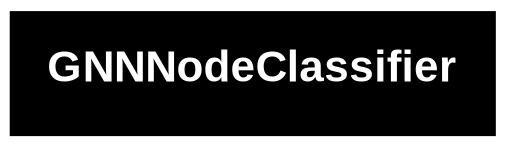

In [66]:
keras.utils.plot_model(gnn_model)

### Train the GNN model

Note that we use the standard *supervised* cross-entropy loss to train the model.
However, we can add another *self-supervised* loss term for the generated node embeddings
that makes sure that neighbouring nodes in graph have similar representations, while faraway
nodes have dissimilar representations.

In [67]:
gnn_history = run_experiment(
    gnn_model,
    train_indices,
    train_labels,
    val_indices,
    val_labels,
)

Epoch 1/300
6/6 - 37s - 6s/step - acc: 0.1471 - loss: 2.2029 - val_acc: 0.3035 - val_loss: 1.8824
Epoch 2/300
6/6 - 0s - 41ms/step - acc: 0.2535 - loss: 1.9778 - val_acc: 0.3035 - val_loss: 1.8719
Epoch 3/300
6/6 - 0s - 26ms/step - acc: 0.2779 - loss: 1.8913 - val_acc: 0.3035 - val_loss: 1.8825
Epoch 4/300
6/6 - 0s - 25ms/step - acc: 0.2764 - loss: 1.8785 - val_acc: 0.3035 - val_loss: 1.8851
Epoch 5/300
6/6 - 0s - 27ms/step - acc: 0.2868 - loss: 1.8455 - val_acc: 0.3035 - val_loss: 1.8803
Epoch 6/300
6/6 - 0s - 29ms/step - acc: 0.2846 - loss: 1.8471 - val_acc: 0.3035 - val_loss: 1.8695
Epoch 7/300
6/6 - 0s - 35ms/step - acc: 0.3001 - loss: 1.8325 - val_acc: 0.3035 - val_loss: 1.8566
Epoch 8/300
6/6 - 0s - 29ms/step - acc: 0.3067 - loss: 1.8077 - val_acc: 0.3134 - val_loss: 1.8446
Epoch 9/300
6/6 - 0s - 29ms/step - acc: 0.3023 - loss: 1.7919 - val_acc: 0.3284 - val_loss: 1.8307
Epoch 10/300
6/6 - 0s - 53ms/step - acc: 0.3274 - loss: 1.7566 - val_acc: 0.3408 - val_loss: 1.8034
Epoch 11/3

Let's plot the learning curves

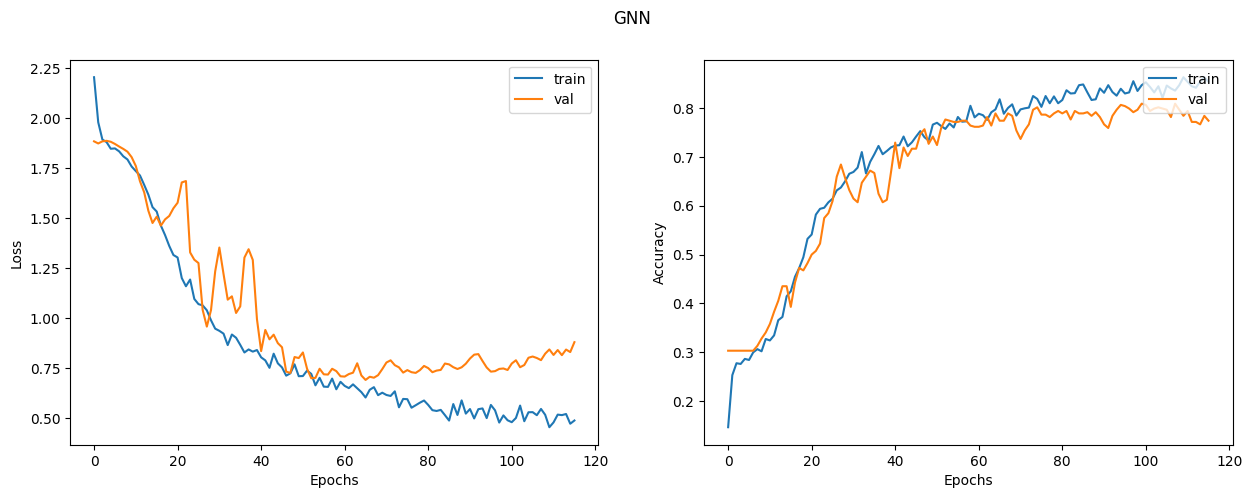

In [68]:
display_learning_curves(gnn_history, title="GNN")

Now we evaluate the GNN model on the test data split.
The results may vary depending on the training sample, however the GNN model always outperforms
the baseline model in terms of the test accuracy.

In [69]:
x_test = test_indices
_, test_accuracy = gnn_model.evaluate(x=test_indices, y=test_labels, verbose=0)
print(f"Test accuracy: {round(test_accuracy * 100, 2)}%")

Test accuracy: 81.22%


### Examine the GNN model predictions

Let's add the new instances as nodes to the `node_features`, and generate links
(citations) to existing nodes.

In [70]:
# First we add the N new_instances as nodes to the graph
# by appending the new_instance to node_features.
num_nodes = int(gnn_model.node_features.shape[0])

new_instances = new_instances.astype("float32")

new_node_features = np.concatenate(
    [ops.convert_to_numpy(gnn_model.node_features), new_instances], axis=0
).astype("float32")

new_node_indices = np.arange(num_nodes, num_nodes + num_classes, dtype="int32")

new_citations = []
for subject_idx, group in papers.groupby("subject"):
    subject_papers = group.paper_id.to_numpy()

    selected_paper_indices1 = np.random.choice(subject_papers, 5, replace=False)

    selected_paper_indices2 = np.random.choice(
        papers.paper_id.to_numpy(), 2, replace=False
    )

    selected_paper_indices = np.concatenate(
        [selected_paper_indices1, selected_paper_indices2], axis=0
    )

    # Create edges between a citing paper idx and the selected cited papers.
    citing_paper_idx = int(new_node_indices[int(subject_idx)])
    for cited_paper_idx in selected_paper_indices:
        new_citations.append([citing_paper_idx, int(cited_paper_idx)])

new_citations = np.array(new_citations, dtype="int32").T
new_edges = np.concatenate(
    [ops.convert_to_numpy(gnn_model.edges), new_citations], axis=1
).astype("int32")

# Optional but recommended for consistency..add self-loops for the NEW nodes too.
new_self_loops = np.stack([new_node_indices, new_node_indices], axis=0).astype("int32")
new_edges = np.concatenate([new_edges, new_self_loops], axis=1)

Now let's update the `node_features` and the `edges` in the GNN model.

In [71]:
print("Original node_features shape:", gnn_model.node_features.shape)
print("Original edges shape:", gnn_model.edges.shape)

# Update model graph
gnn_model.node_features = ops.convert_to_tensor(new_node_features, dtype="float32")
gnn_model.edges = ops.convert_to_tensor(new_edges, dtype="int32")
gnn_model.edge_weights = ops.ones(shape=(new_edges.shape[1],), dtype="float32")

print("New node_features shape:", gnn_model.node_features.shape)
print("New edges shape:", gnn_model.edges.shape)

# Predict on the new nodes
logits = gnn_model(
    ops.convert_to_tensor(new_node_indices, dtype="int32"), training=False
)
probabilities = ops.convert_to_numpy(ops.softmax(logits))
display_class_probabilities(probabilities)

Original node_features shape: (2708, 1433)
Original edges shape: (2, 8137)
New node_features shape: (2715, 1433)
New edges shape: (2, 8193)
Instance 1:
- Case_Based: 5.050000190734863%
- Genetic_Algorithms: 1.8899999856948853%
- Neural_Networks: 8.5600004196167%
- Probabilistic_Methods: 1.3799999952316284%
- Reinforcement_Learning: 4.760000228881836%
- Rule_Learning: 10.010000228881836%
- Theory: 68.33999633789062%
Instance 2:
- Case_Based: 1.0800000429153442%
- Genetic_Algorithms: 78.3499984741211%
- Neural_Networks: 2.1600000858306885%
- Probabilistic_Methods: 0.9300000071525574%
- Reinforcement_Learning: 16.18000030517578%
- Rule_Learning: 0.28999999165534973%
- Theory: 1.0299999713897705%
Instance 3:
- Case_Based: 2.2100000381469727%
- Genetic_Algorithms: 1.9199999570846558%
- Neural_Networks: 62.88999938964844%
- Probabilistic_Methods: 7.380000114440918%
- Reinforcement_Learning: 3.109999895095825%
- Rule_Learning: 5.070000171661377%
- Theory: 17.40999984741211%
Instance 4:
- Case

Notice that the probabilities of the expected subjects
(to which several citations are added) are higher compared to the baseline model.

## Relevant Chapters from Deep Learning with Python
- [Chapter 7: A deep dive on Keras](https://deeplearningwithpython.io/chapters/chapter07_deep-dive-keras)